In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
import pandas as pd
df = pd.read_excel("bank_marketing_custom_dataset.xlsx")

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,previous,y
0,19,student,divorced,primary,yes,43212,no,no,telephone,468,9,0,no
1,29,retired,single,tertiary,no,18334,no,no,cellular,571,3,2,yes
2,34,admin,divorced,tertiary,no,11380,yes,no,telephone,1510,7,0,yes
3,46,management,single,secondary,yes,8152,no,no,cellular,1450,7,0,yes
4,69,retired,married,primary,yes,47908,no,no,cellular,1548,5,2,yes


In [8]:
print(df.shape)

(300, 13)


In [9]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'duration', 'campaign', 'previous', 'y'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        300 non-null    int64 
 1   job        300 non-null    object
 2   marital    300 non-null    object
 3   education  300 non-null    object
 4   default    300 non-null    object
 5   balance    300 non-null    int64 
 6   housing    300 non-null    object
 7   loan       300 non-null    object
 8   contact    300 non-null    object
 9   duration   300 non-null    int64 
 10  campaign   300 non-null    int64 
 11  previous   300 non-null    int64 
 12  y          300 non-null    object
dtypes: int64(5), object(8)
memory usage: 30.6+ KB


In [11]:
df.describe()

,age,balance,duration,campaign,previous
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,43.583333,24002.583333,950.636667,5.570000,2.563333
std,16.137258,14766.593785,567.511305,2.918933,1.715361
min,18.000000,-280.000000,36.000000,1.000000,0.000000
25%,29.750000,11170.250000,452.750000,3.000000,1.000000
50%,44.000000,23108.000000,955.000000,6.000000,2.000000
75%,58.000000,36417.750000,1450.500000,8.000000,4.000000
max,70.000000,49922.000000,1993.000000,10.000000,5.000000


In [12]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
duration,0


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,previous,y
0,19,4,0,0,1,43212,0,0,1,468,9,0,0
1,29,2,2,2,0,18334,0,0,0,571,3,2,1
2,34,0,0,2,0,11380,1,0,1,1510,7,0,1
3,46,1,2,1,1,8152,0,0,0,1450,7,0,1
4,69,2,1,0,1,47908,0,0,0,1548,5,2,1


In [15]:
X = df.drop("y", axis=1)

y = df["y"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 12)
(60, 12)
(240,)
(60,)


In [20]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

In [21]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
print(y_pred)

[1 1 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1
 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 1 1 0 0 1 1]


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7833333333333333


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.67      0.71        24
           1       0.79      0.86      0.83        36

    accuracy                           0.78        60
   macro avg       0.78      0.76      0.77        60
weighted avg       0.78      0.78      0.78        60



In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16  8]
 [ 5 31]]


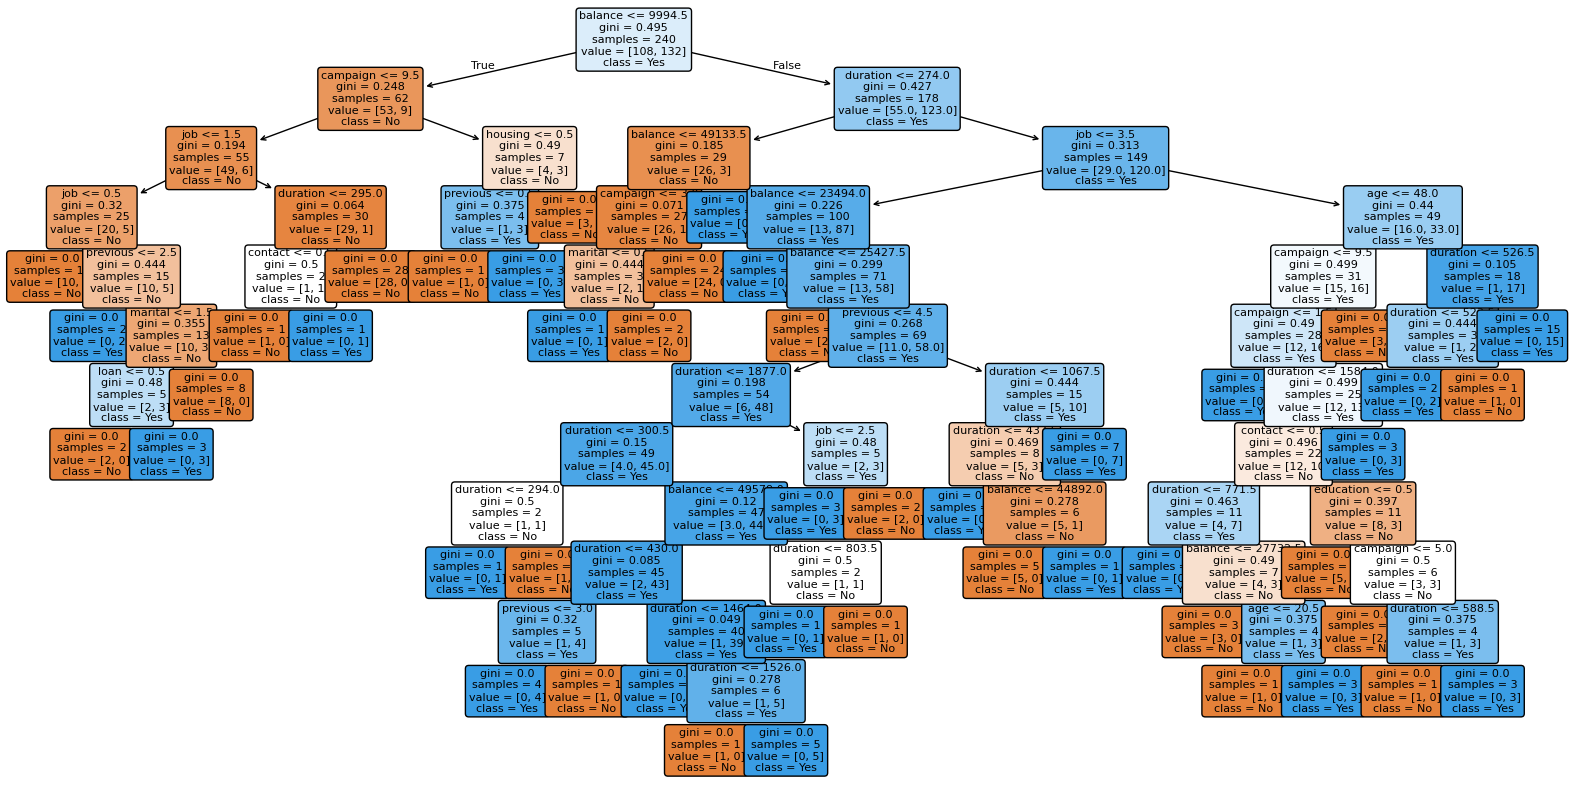

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

      Feature  Importance
9    duration    0.356463
5     balance    0.331417
1         job    0.059186
10   campaign    0.053570
11   previous    0.053120
0         age    0.047797
2     marital    0.029871
8     contact    0.020661
7        loan    0.020202
6     housing    0.016234
3   education    0.011478
4     default    0.000000


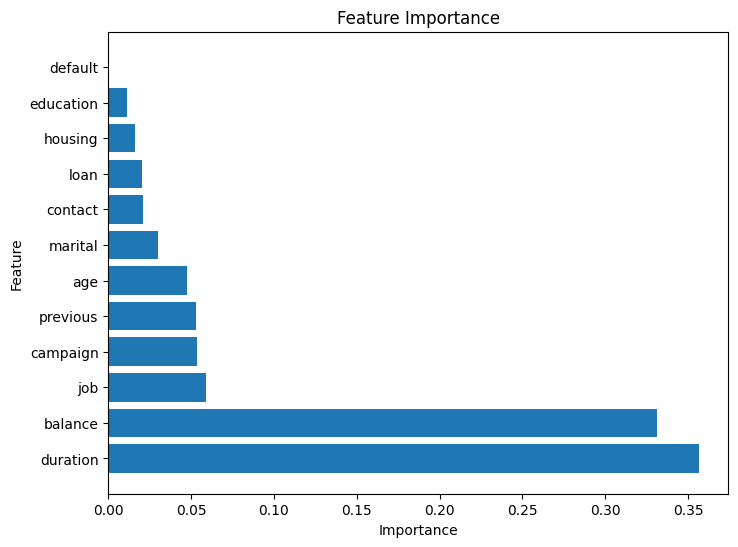

In [34]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.show()

In [35]:
print("Decision Tree model built successfully!")
print("Model Accuracy:", accuracy)

Decision Tree model built successfully!
Model Accuracy: 0.7833333333333333
